   YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO    APT_NAME STATE_NAME  \
0  2025          1       JAN  2025-01-01     LATI      Tirana    Albania   
1  2025          1       JAN  2025-01-01     UDYZ     Yerevan    Armenia   
2  2025          1       JAN  2025-01-01     LOWG        Graz    Austria   
3  2025          1       JAN  2025-01-01     LOWI   Innsbruck    Austria   
4  2025          1       JAN  2025-01-01     LOWK  Klagenfurt    Austria   

   FLT_DEP_1  FLT_ARR_1  FLT_TOT_1  FLT_DEP_IFR_2  FLT_ARR_IFR_2  \
0         64         62        126            NaN            NaN   
1         57         54        111            NaN            NaN   
2          7          6         13            NaN            NaN   
3         24         25         49            NaN            NaN   
4          2          0          2            NaN            NaN   

   FLT_TOT_IFR_2  
0            NaN  
1            NaN  
2            NaN  
3            NaN  
4            NaN  
<class 'pandas.core.

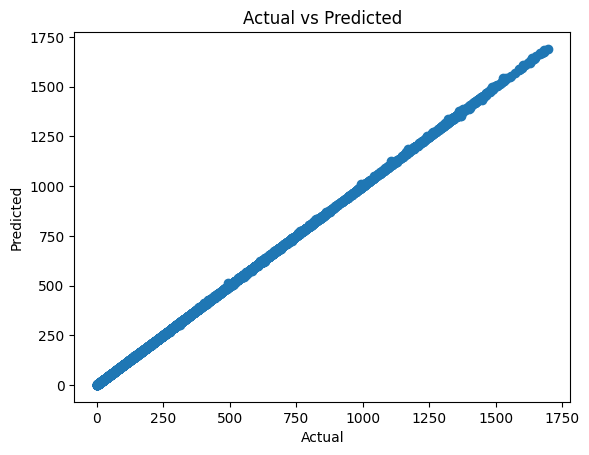

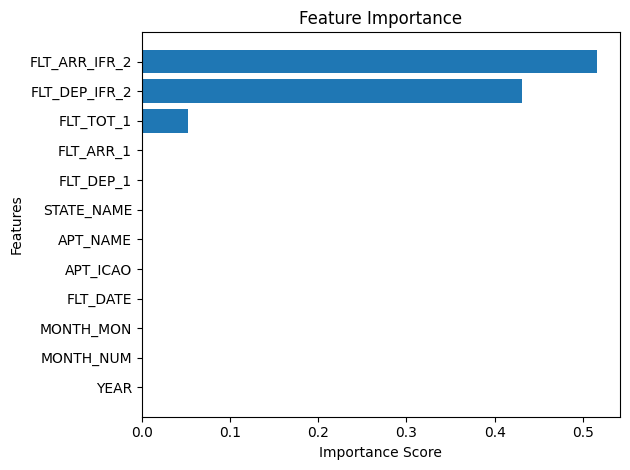


Model saved successfully!


In [4]:
#  1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

#  2. Load Dataset
df = pd.read_csv("/content/drive/MyDrive/airport_traffic_2025.csv")

print(df.head())
print(df.info())

#  3. Data Cleaning
# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Drop duplicates
df.drop_duplicates(inplace=True)

#  4. Encode Categorical Columns
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

#  5. Feature Engineering
# Example (adapt based on dataset columns)
if "Month" in df.columns:
    df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

# 6. Features & Target
# Change target depending on dataset
target = "Passengers" if "Passengers" in df.columns else df.columns[-1]

X = df.drop(columns=[target])
y = df[target]

#  7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

feature_names = X.columns

# 8. Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 9. Model Training
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

#  10. Prediction
y_pred = model.predict(X_test)

#  11. Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nMAE:", mae)
print("RMSE:", rmse)

#  12. Visualization
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

# 13. Feature Importance
importance = model.feature_importances_

plt.figure()
plt.barh(feature_names, importance)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

#  14. Save Model
import joblib
joblib.dump(model, "air_traffic_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nModel saved successfully!")